# Numerische Integration


## Vertiefung


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Übersicht


1. Trapezformel vektorisiert implementieren
2. Fehlerabschätzung
3. Trapezformel für Daten mit ungleichmässigen Abständen
4. Integration mit SciPy


### 1. Trapezformel vektorisiert implementieren


Vorgehen beim Integrieren mit der [Trapezregel](https://de.wikipedia.org/wiki/Trapezregel):

-   Zerlege das Intervall $[a,b]$ in $n$ gleich breite Intervalle.
-   Berechne Funktionswerte an den Intervallgrenzen und verbinde diese mit Geraden, so dass $n$ Trapeze entstehen.
-   Berechne die Flächen der Trapeze.
-   Die Summe aller Flächen ergibt eine Näherung des Integrals.
-   Je grösser $n$ desto genauer das Ergebnis.

$$
    T_n = \frac{h}{2} \left( f(a) + 2\sum_{i=1}^{n-1} f(a + ih) + f(b) \right)
    \,,\qquad\text{wobei}\quad h = \frac{b-a}{n}
$$


In [2]:
def trapz_comprehension(func, a, b, n):
    h = (b - a) / n
    s = sum([func(a + i * h) for i in range(1, n)])
    return (h / 2) * (func(a) + 2 * s + func(b))

In [3]:
def trapz_vectorized(func, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = func(x)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

Test mit der Funktion

$$
    f(x) = \sin(x)
$$

[Analytisches Resultat](https://www.wolframalpha.com/input?i=int+sin%28x%29+from+0+to+pi):

$$
    \int_0^{\pi} \sin(x) \,dx
    = \Big[ -\cos(x) \Big]_0^{\pi}
    = -\cos(\pi)+\cos(0) = 2
$$

Beide Implementationen vergleichen:


In [4]:
n = 1000
T1 = trapz_comprehension(np.sin, 0, np.pi, n)
T2 = trapz_vectorized(np.sin, 0, np.pi, n)
T1, T2, T1 - T2

(np.float64(1.9999983550656624),
 np.float64(1.9999983550656624),
 np.float64(0.0))

Laufzeit vergleichen mit `%timeit`:


In [5]:
%timeit trapz_comprehension(np.sin, 0, np.pi, n)
%timeit trapz_vectorized(np.sin, 0, np.pi, n)

517 μs ± 9.18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
12 μs ± 216 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### 2. Fehlerabschätzung


#### Explorativ

Abhängigkeit des Fehlers von $n$. Beispiel von oben.


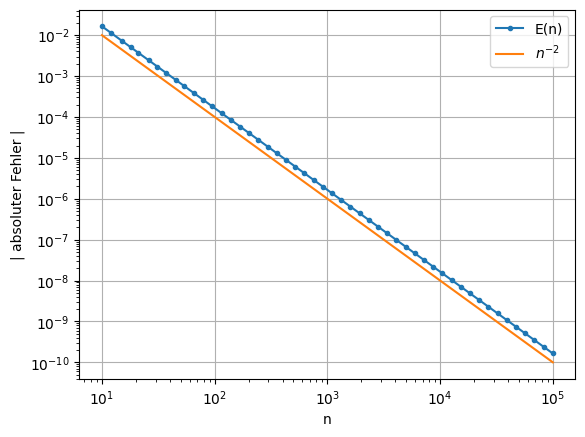

In [6]:
ns = np.logspace(1, 5).round().astype(int)
# ns = np.array([10, 100, 1000, 10000, 100000])
errors = np.array([abs(trapz_vectorized(np.sin, 0, np.pi, n) - 2) for n in ns])

plt.loglog(ns, errors, ".-", label="E(n)")
plt.loglog(ns, ns.astype(float) ** (-2), "-", label="$n^{-2}$")
plt.xlabel("n")
plt.ylabel("| absoluter Fehler |")
plt.grid()
plt.legend()
plt.show()

Der Fehler $E(n)$ ist eine Gerade im Log-Log-Plot. Das heisst, es handelt sich um eine Potenzfunktion

$$ E(n) = C \cdot n^p $$

und $p$ ist die Steigung der Geraden im Log-Log-Plot. Berechnen wir also mal die Steigung zwischen je zwei Punkten und mitteln diese:


In [7]:
np.mean(np.diff(np.log10(errors)) / np.diff(np.log10(ns)))

np.float64(-2.0001764354362734)

#### Trapezregel Abschätzung

Eine analytische [Fehlerabschätzung ist in Wikipedia](https://de.wikipedia.org/wiki/Trapezregel#Fehlerabsch%C3%A4tzung) zu finden. Der Fehler

$$
    E_n = T_n - \int_a^b (x) \,dx
$$

ist beschränkt durch

$$
    \left| E_n \right|
    \leq \frac{(b-a)}{12}\cdot M_2\cdot h^2
    = \frac{(b-a)^3}{12}\cdot M_2 \cdot n^{-2}
$$

wobei

$$
    M_2 = \max_{a \leq x \leq b} \left| f''(x) \right|
$$

Das heisst, der Fehler ist proportional zu $h^2$ bzw. $n^{-2}$, wie wir oben bereits gesehen haben.

Zudem ist der Fehler auch proportional zum Maximum der zweiten Ableitung der Funktion, $M_2$. Das heisst, je stärker die Funktion im Intervall $[a,b]$ schwankt (grössere Krümmung), desto grösser ist der Fehler durch die Näherung mit der Trapezregel.

Folgende Videos gehen auf die Fehlerabschätzung ein (optional):

-   [Fehler der Trapezregel für numerische Integration - Jörn Loviscach](https://youtu.be/JwPlWzP-K1A)
-   [Analysis Numerische Integration: Trapezformel Abschätzung des Fehlers (Trapezregel) - Henning Dierks](https://youtu.be/PifHwEaUxoo)


### 3. Trapezformel für Daten mit ungleichmässigen Abständen


#### Beispiel-Daten erzeugen


Wir generieren ein paar Datenpunkte, die nicht gleichmässig verteilt sind. Die $x$-Werte werden zufällig gleichverteilt über das Intervall $[0, 3]$ generiert. Die $y$-Werte sind die Funktionswerte der Funktion

$$
    f(x) = 1 - (x+1)(x-2)
$$


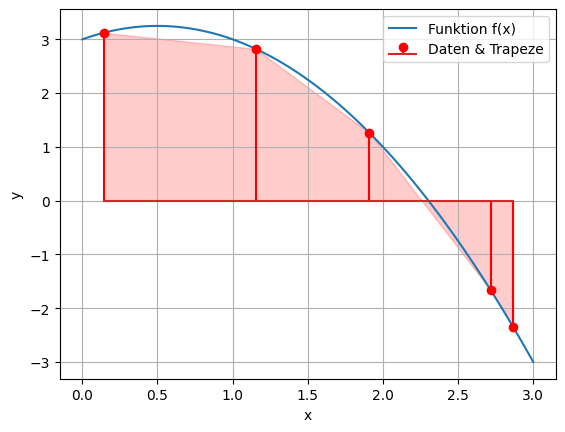

In [8]:
def f(x):
    return 1 - (x + 1) * (x - 2)


x = np.linspace(0, 3, 100)
y = f(x)

n_samples = 5
rng = np.random.default_rng(123456)
x_data = np.sort(rng.uniform(low=x.min(), high=x.max(), size=n_samples))
y_data = f(x_data)

plt.plot(x, y, label="Funktion f(x)")
plt.stem(x_data, y_data, "r", label="Daten & Trapeze")
plt.fill_between(x_data, y_data, 0, alpha=0.2, color="r")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

#### Trapezformel für Daten


Die Trapezformel für $n$ Datenpunkte mit $(x_i, y_i)$ mit $i=0,\ldots,n-1$ ungleichmässigen Abständen lautet:

$$
    T_n = \frac{1}{2} \sum_{k=1}^{n-1} \left( x_{k} - x_{k-1} \right) \left( y_{k} + y_{k-1} \right)
$$

Hier ist

-   $\Delta x_k = x_{k} - x_{k-1}$ die Breite des $k$-ten Trapezes und
-   $\frac{1}{2} \left( y_{k} + y_{k-1} \right)$ die mittlere Höhe des $k$-ten Trapezes.

Die Formel wird hier erklärt:

-   [Analysis Numerische Integration: Trapezformel #13-55 - Henning Dierks](https://youtu.be/8i6KtWTec6c)


#### Implementation als Comprehension


In [9]:
def trapz_data_comprehension(x, y):
    terms = [(x[k] - x[k - 1]) * (y[k] + y[k - 1]) for k in range(1, len(x))]
    return sum(terms) / 2


trapz_data_comprehension(x_data, y_data)

np.float64(4.089099472806035)

#### Vektorisierte Implementation


In [10]:
def trapz_data_vectorized(x, y):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1])) / 2


trapz_data_vectorized(x_data, y_data)

np.float64(4.089099472806035)

#### Vergleich mit analytischen Resultat

Das analytische Resultat ist:

\begin{align*}
    \int_0^3 1 - (x+1)(x-2) \,dx
    &= \int_0^3 -x^2 + x + 3 \,dx \\[1ex]
    &= \Big[ -\frac{1}{3}x^3 + \frac{1}{2}x^2 + 3x \Big]_0^3 \\[1ex]
    &= -\frac{27}{3} + \frac{9}{2} + 3\cdot 3 \\[1ex]
    &= 4.5
\end{align*}

Siehe auch https://www.wolframalpha.com/input?i=int+1-%28x%2B1%29%28x-2%29+from+0+to+3.

#### Vergleich der Performance


In [11]:
%timeit trapz_data_comprehension(x_data, y_data)
%timeit trapz_data_vectorized(x_data, y_data)

1.52 μs ± 89.9 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
3.58 μs ± 118 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### 4. Integration mit SciPy


-   Übersichtsseite: [SciPy-Integration](https://docs.scipy.org/doc/scipy/reference/integrate.html)
-   Tutorial: [SciPy-Integration](https://docs.scipy.org/doc/scipy/tutorial/integrate.html)
-   Integration von Funktionen mit [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.html)
-   Integration von Daten mit [`scipy.integrate.trapezoid`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.trapezoid.html)


In [12]:
from scipy.integrate import quad, trapezoid

#### Integration von Funktionen


In [13]:
quad(np.sin, 0, np.pi)

(2.0, 2.220446049250313e-14)

In [14]:
n = 10_000_000
trapz_vectorized(np.sin, 0, np.pi, n) - quad(np.sin, 0, np.pi)[0]

np.float64(-1.7319479184152442e-14)

In [15]:
%timeit trapz_vectorized(np.sin, 0, np.pi, n)
%timeit quad(np.sin, 0, np.pi)[0]

85.6 ms ± 4.62 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
13.3 μs ± 639 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Dem Integranden können auch zusätzliche Argumente übergeben werden. Beispiel:


In [16]:
def g(t, omega):
    return np.sin(omega * t)


[
    (omega, quad(g, 0, np.pi, args=(omega,))[0])
    for omega in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
]

[(1, 2.0),
 (2, 1.1107507412563885e-16),
 (3, 0.6666666666666666),
 (4, -5.1403259861772137e-17),
 (5, 0.4),
 (6, 4.426090313079715e-17),
 (7, 0.28571428571428553),
 (8, -4.092757252790816e-16),
 (9, 0.2222222222222224),
 (10, -7.281558691778114e-16)]

Auch uneigentliche Integrale (mit unendlichem Intervall) können näherungsweise berechnet werden:

\begin{align*}
\int_0^{\infty} e^{-x} \,dx
&= \lim_{b\to\infty} \, \int_0^{b} e^{-x} \,dx \\[1ex]
&= \lim_{b\to\infty} \, \Big[ -e^{-x} \Big]_0^b \\[1ex]
&= \lim_{b\to\infty} \, \left( 1 - e^{-b} \right) \\[1ex]
&= 1
\end{align*}


In [17]:
quad(lambda x: np.exp(-x), 0, np.inf)

(1.0000000000000002, 5.842606703608969e-11)

#### Integration über Daten


In [18]:
trapezoid(y_data, x_data)

np.float64(4.089099472806035)

In [19]:
trapz_data_vectorized(x_data, y_data) - trapezoid(y_data, x_data)

np.float64(0.0)

In [20]:
%timeit trapezoid(y_data, x_data)
%timeit trapz_data_vectorized(x_data, y_data)

10.8 μs ± 282 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
3.67 μs ± 257 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
